# IPL Match Data Analysis

## Applying Descriptive Statistics & Data Visualization on IPL Match Data

### Objective
The goal of this project is to apply descriptive statistics and visualization techniques to IPL match data and extract meaningful insights from historical match records.

Concepts Applied:
- Types of Data
- Measures of Central Tendency
- Measures of Spread
- Outlier Detection
- Histograms
- KDE Plots
- Boxplots
- Countplots
- Crosstabs
- Exploratory Data Analysis (EDA)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels import robust


sns.set_style("whitegrid")

In [2]:
match=pd.read_csv('matches.csv')
delivery=pd.read_csv('deliveries.csv')

DATASET OVERVIEW!

In [ ]:
match.head()


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [ ]:
delivery.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [ ]:
match.columns

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')

In [ ]:
delivery.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')

In [ ]:
match.shape

(1095, 20)

In [ ]:
delivery.shape

(260920, 17)

In [ ]:
match.dtypes

,0
id,int64
season,object
city,object
date,object
match_type,object
player_of_match,object
venue,object
team1,object
team2,object
toss_winner,object


HANDLING MISSING VALUES

In [ ]:
match.isnull().sum()

,0
id,0
season,0
city,51
date,0
match_type,0
player_of_match,5
venue,0
team1,0
team2,0
toss_winner,0


In [ ]:
match["city"]=match["city"].fillna("Undefined")
match["winner"]=match["winner"].fillna("Draw")
match["player_of_match"]=match["player_of_match"].fillna("No Player of Match")
match["method"]=match["method"].fillna("No Method")
match["target_runs"]=match["target_runs"].fillna(0)
match["result_margin"]=match["result_margin"].fillna(0)
match["target_overs"]=match["target_overs"].fillna(0)


In [ ]:
match.isnull().sum()

,0
id,0
season,0
city,0
date,0
match_type,0
player_of_match,0
venue,0
team1,0
team2,0
toss_winner,0


DATA CATEGORIES:

Numerical:
- season
- result_margin
- target_runs
- target_overs

Categorical:
- winner
- city
- venue
- toss_winner
- player_of_match

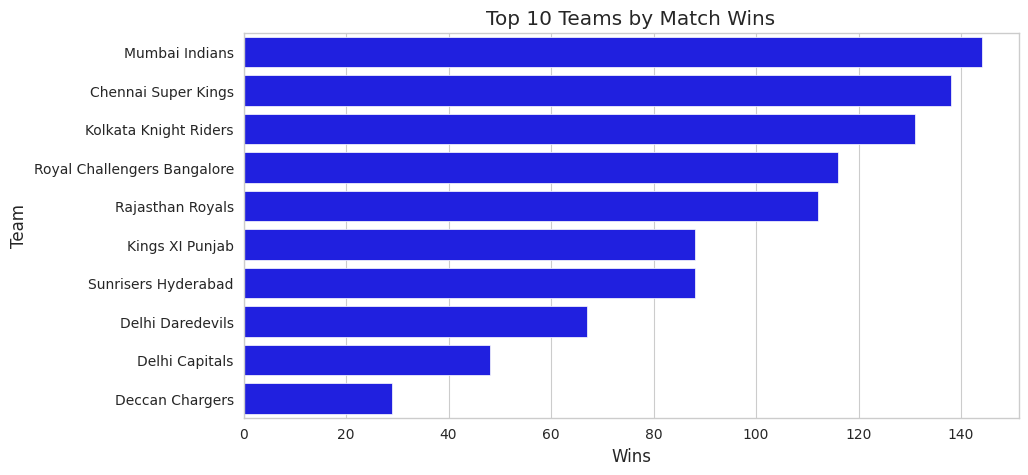

In [ ]:
winner_counts = match['winner'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=winner_counts.values,
            y=winner_counts.index,color="blue")
plt.title("Top 10 Teams by Match Wins")
plt.xlabel("Wins")
plt.ylabel("Team")
plt.show()

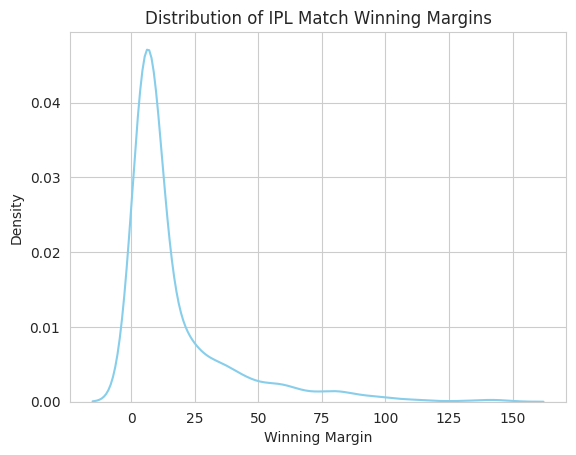

In [4]:
sns.kdeplot(match["result_margin"],color="skyblue")

plt.title("Distribution of IPL Match Winning Margins")
plt.xlabel("Winning Margin")
plt.ylabel("Density")

plt.show()


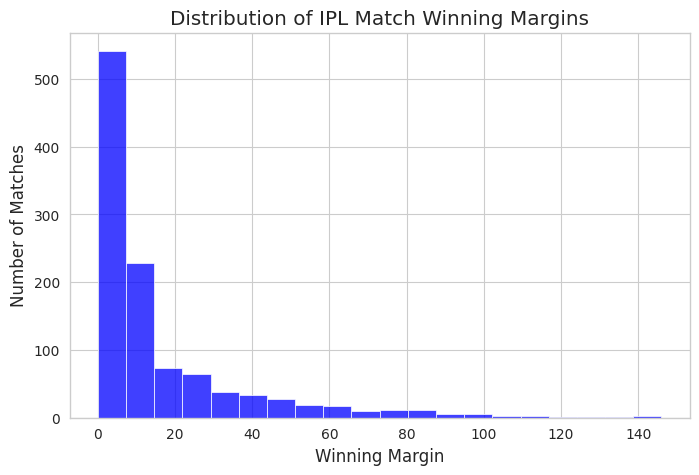

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(match['result_margin'].dropna(),
             bins=20,
             color='blue')

plt.title('Distribution of IPL Match Winning Margins')
plt.xlabel('Winning Margin')
plt.ylabel('Number of Matches')

plt.show()

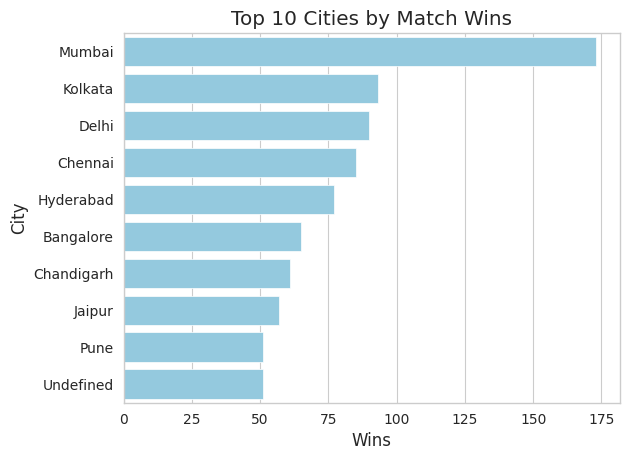

In [ ]:
top_cities=match["city"].value_counts().head(10)

sns.barplot(x=top_cities.values,y=top_cities.index,color='skyblue')
plt.title("Top 10 Cities by Match Wins")
plt.xlabel("Wins")
plt.ylabel("City")
plt.show()

Text(0, 0.5, 'Density')

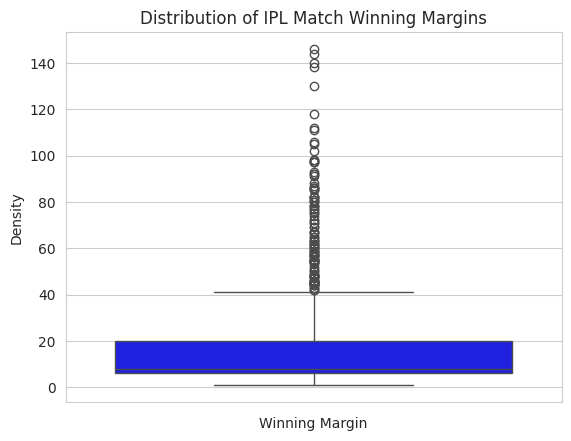

In [5]:
sns.boxplot(match["result_margin"],color="blue")

plt.title("Distribution of IPL Match Winning Margins")
plt.xlabel("Winning Margin")
plt.ylabel("Density")

<Axes: xlabel='result', ylabel='result_margin'>

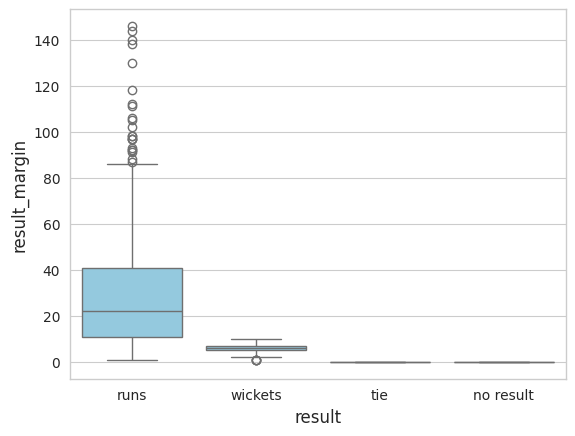

In [ ]:
sns.boxplot(x="result",y="result_margin",data=match,color="skyblue")

<Axes: xlabel='super_over', ylabel='result_margin'>

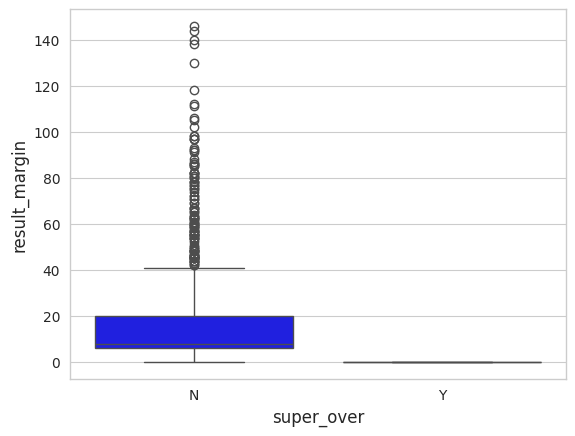

In [ ]:
sns.boxplot(x="super_over",y="result_margin",data=match,color="blue")

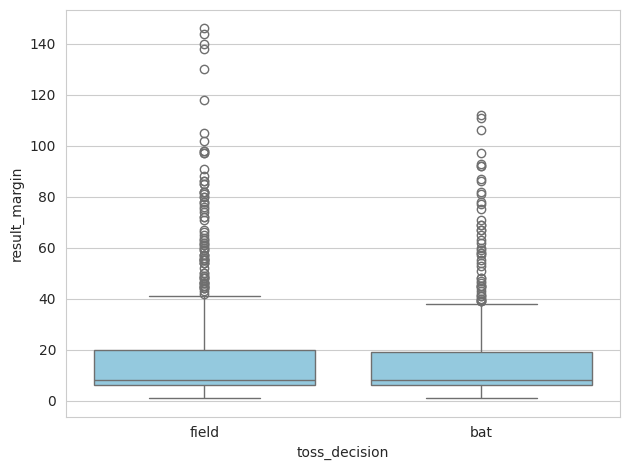

In [ ]:
sns.boxplot(
    x="toss_decision",
    y="result_margin",
    data=match,
    color="skyblue"
)

plt.tight_layout()
plt.show()

<Axes: >

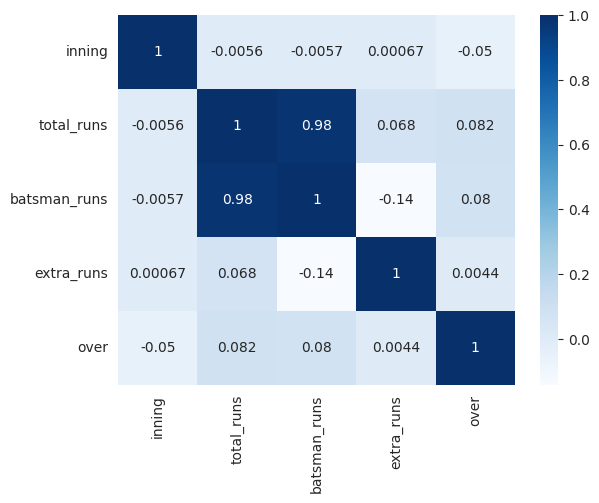

In [ ]:
num_cols=["inning","total_runs","batsman_runs","extra_runs","over"]

sns.heatmap(delivery[num_cols].corr(),annot=True,cmap='Blues')

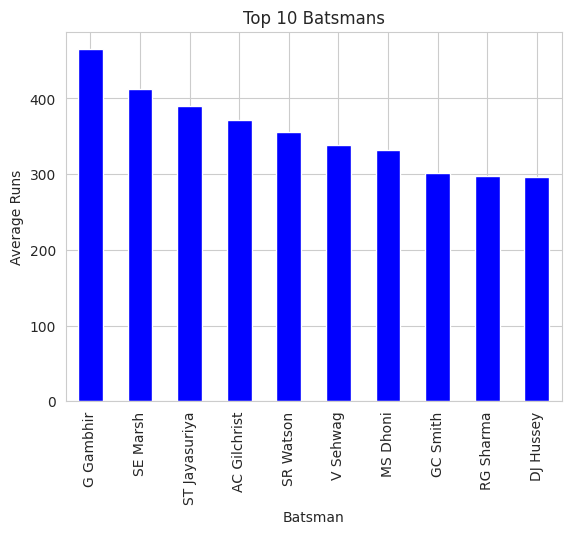

In [ ]:
top_batsman=delivery.groupby("batter")["batsman_runs"].sum().sort_values(ascending=False).head(10)

top_batsman.plot(kind="bar",color="blue")
plt.title("Top 10 Batsmans")
plt.xlabel("Batsman")
plt.ylabel("Average Runs")
plt.show()

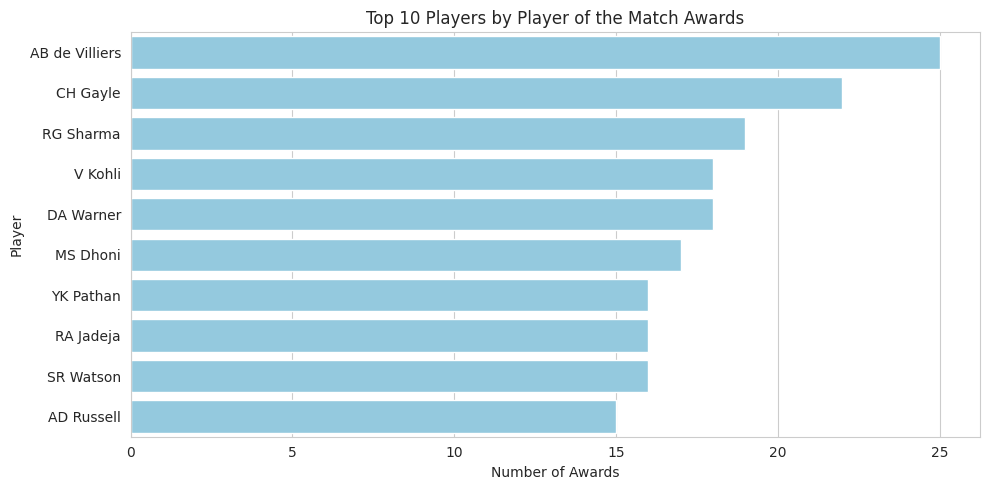

In [ ]:
pom = match["player_of_match"].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=pom.values,
    y=pom.index,
    color="skyblue"
)

plt.title("Top 10 Players by Player of the Match Awards")
plt.xlabel("Number of Awards")
plt.ylabel("Player")

plt.tight_layout()
plt.show()

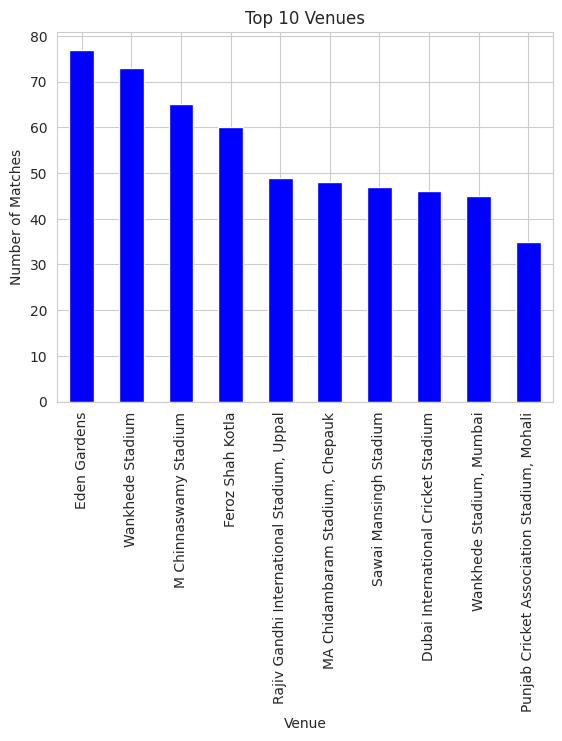

In [ ]:
top_venue=match["venue"].value_counts().head(10)

top_venue.plot(kind="bar",color="blue")
plt.title("Top 10 Venues")
plt.xlabel("Venue")
plt.ylabel("Number of Matches")
plt.show()

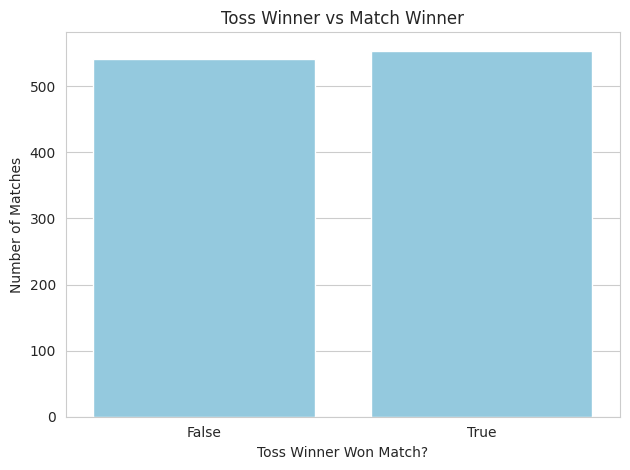

In [ ]:
sns.countplot(
    x=(match["toss_winner"] == match["winner"]),
    color="skyblue"
)

plt.title("Toss Winner vs Match Winner")
plt.xlabel("Toss Winner Won Match?")
plt.ylabel("Number of Matches")
plt.tight_layout()
plt.show()

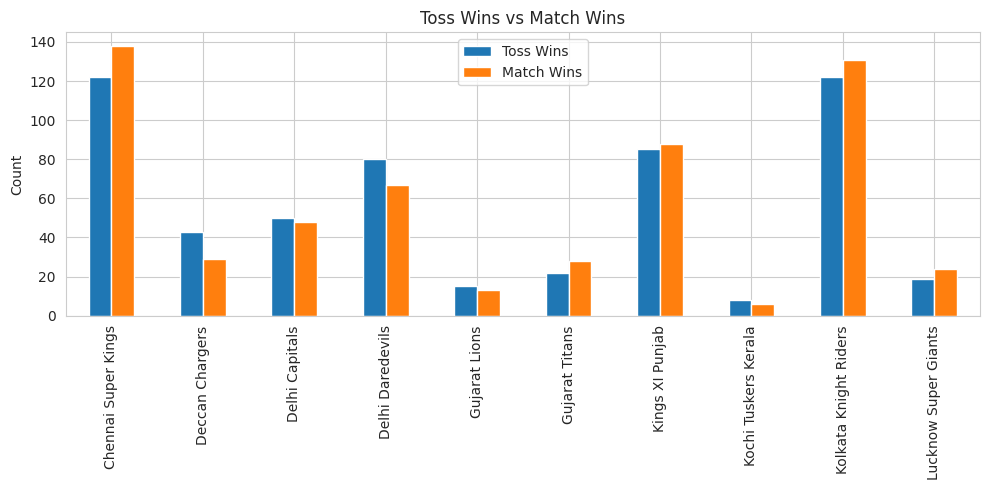

In [ ]:
toss = match["toss_winner"].value_counts()
wins = match["winner"].value_counts()

comparison = pd.DataFrame({
    "Toss Wins": toss,
    "Match Wins": wins
}).fillna(0)

comparison.head()
comparison.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Toss Wins vs Match Wins")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

palette = "Blues_r"

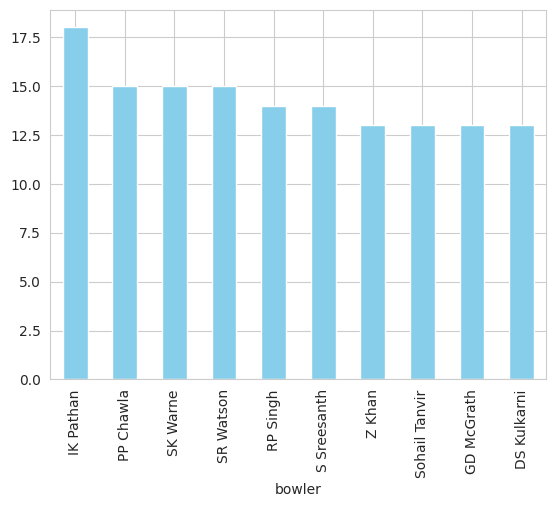

In [ ]:
top_wicket_takers=delivery.groupby("bowler")["is_wicket"].sum().sort_values(ascending=False).head(10)

top_wicket_takers.plot(kind="bar",color="skyblue")

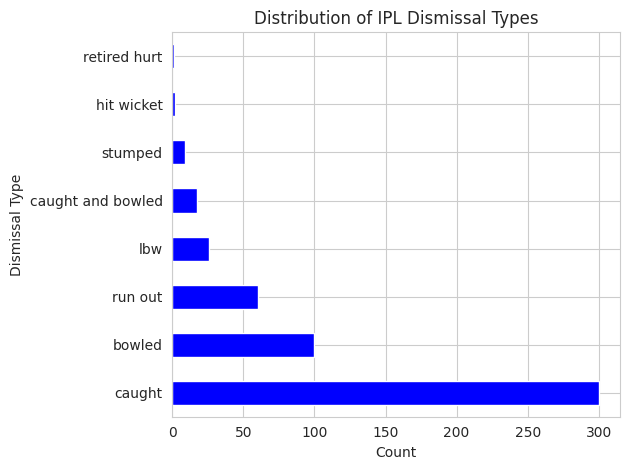

In [ ]:
delivery["dismissal_kind"].value_counts().plot(
    kind="barh",
    color="blue"
)

plt.title("Distribution of IPL Dismissal Types")
plt.xlabel("Count")
plt.ylabel("Dismissal Type")

plt.tight_layout()
plt.show()

In [ ]:
match.columns

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')

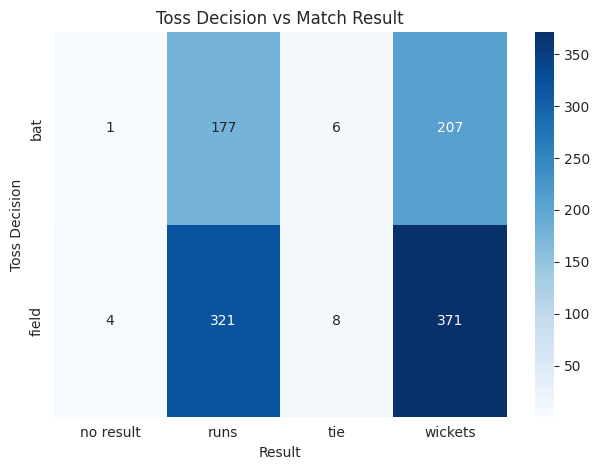

In [ ]:
analysis=pd.crosstab(match["toss_decision"],match["result"])

sns.heatmap(analysis,annot=True,cmap="Blues",fmt='d')

plt.title("Toss Decision vs Match Result")
plt.xlabel("Result")
plt.ylabel("Toss Decision")

plt.tight_layout()
plt.show()

### Toss Decision vs Match Result

A crosstab heatmap was used to study the relationship between toss decisions and match outcomes.

Observations:
- Teams chose to field first more frequently than batting first.
- Wins by wickets were more common than wins by runs.
- Teams that elected to field first recorded the highest number of wicket-based victories.

This suggests that chasing has historically been a preferred strategy in the IPL, as teams can make decisions based on a known target.